# Анализ данных на Python
## Операции с датафреймами Pandas: часть 1

*Алла Тамбовцева, НИУ ВШЭ*

Содержание конспекта:

* Загрузка данных
* Знакомство с данными: техническое описание и описательные статистики
* Работа со столбцами датафрейма: добавление и описание
* Работа со столбцами датафрейма: создание новых столбцов на основе старых
* Переименование и удаление столбцов и строк
* Группировка и агрегирование
* Немного о мультииндексах
* Фильтрация строк по условиям

### Загрузка данных

Библиотека `pandas` позволяет создавать датафреймы – удобные структуры для данных в табличном виде. Датафрейм можно получить из списка списков, из списка словарей, из словаря, простого или сложного. Но если наша задача – не преобразовать собранные данные (например, выгруженные из веб-страницы), а обработать уже готовые из имеющегося файла, библиотека `pandas` тоже будет чрезвычайно полезна. Импортируем её с сокращённым названием `pd`:

In [1]:
import pandas as pd

Библиотека `pandas` умеет загружать данные из файлов разных форматов. Среди них файлы Excel (расширения `.xls` и `.xlsx`), Stata (расширение `.dta`), SPSS (расширение `.sav`), текстовые файлы в формате TXT, CSV, JSON и другие. Мы поработаем с форматом CSV, одним из самых распространённых машиночитаемых форматов, название которого расшифровывается как *Comma Separated Values*, то есть «значения, разделённые запятыми».

На практике можно столкнуться и с менее классическими вариантами этого формата. Например, если открыть файл CSV в Excel, он автоматически изменит разделитель `,` на `;`, чтобы точно не перепутать запятую как разделитель столбцов и запятую как десятичный разделить (между целой и дробной частью в числах). В таких случаях символ для разделителя нужно будет указать внутри аргумента `sep` в соответствующей функции, например, `sep = ";"`.

Перейдём к нашему файлу `ab_testing.csv`. Если файл сохранён на компьютере, у нас два пути:

* Поместить его в рабочую папку (рядом с ipynb-файлом, в котором пишем код для загрузки данных) через кнопку *Upload* на главной странице *Home* в Jupyter.
* Найти файл на компьютере и скопировать полный путь к файлу из его расположения.

В первом случае всё просто, вызываем функцию `read_csv()` и помещаем в неё название файла в виде строки:

In [2]:
df = pd.read_csv("ab_testing.csv")

Во втором случае нужно учесть важный момент: слэши в пути должны быть такие `/`, а не такие `\`. Слэш в обратную сторону внутри строки Python воспринимает как специальный символ, плюс, сочетание `\U`, которое неизбежно возникает при наличии папки `Users` будет намекать Python на кодировку символов в Unicode. На Mac и Linux таких слэшей в пути к файлу не возникает, а на Windows, чтобы не заменять каждый слэш вручную, можно перед кавычками поставить букву `r`:

In [3]:
#df = pd.read_csv(r"C:\Users\student\Desktop\ab_testing.csv")

Также файл можно загрузить по ссылке, например, если он лежит на Github:

In [4]:
df = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyPerm25/refs/heads/main/ab_testing.csv")

*Примечание для Google Colab.* Загрузить файл с данными в облачное хранилище можно через кнопку `Files` (значок папки слева от рабочей области с ячейками), при нажатии на которую появляется возможность выбрать файл с компьютера (значок стрелки). После добавления файла его можно выбрать, кликнуть на три точки справа от названия, скопировать путь через *Copy path* и вставить его в функцию `read_csv()`.

Итак, если никаких сообщений об ошибках не было (если `FileNotFoundError`, файл не найден, проверьте, нет ли опечаток в названии, и лежит ли файл в той папке, к которой мы прописали путь или в которой лежит текущий ipynb-файл), данные благополучно сохранились в виде датафрейма `df`.

*Примечание.* Если вы планируете работать с файлами Excel, логика та же, только функция будет `read_excel()`. По умолчанию она считывает только первый лист файла, но в аргументе `sheet_name` можно указать индекс или название листа. Про другие, более продвинутые, опции вроде тех, что позволяют пропускать первые несколько строк в файле или, наоборот, загружать только определенный фрагмент таблицы, можно узнать, запросив `help(pd.read_excel)`.

### Знакомство с данными

В файле `ab_testing.csv` (взят с [Kaggle](https://www.kaggle.com/datasets/adarsh0806/ab-testing-practice)) сохранены результаты *имитации* AB-тестирования дизайна сайта. Предполагается, что пользователи случайным образом попадали на текущую версию сайта с белым цветом страниц (контрольная группа A) или на обновлённую версию сайта с чёрным цветом страниц (тестовая группа B). В ходе эксперимента фиксировалось, сколько веб-страниц было просмотрено в рамках одной сессии нахождения на сайте, сколько времени было затрачено на сессию, выполнил ли пользователь желаемые действия или нет (конверсия), с какого устройства и из какого региона он заходил.

Переменные в файле:

* `User ID`: id ;
* `Group`: группа (`A` и `B`);
* `Page Views`: число просмотренных страниц в рамках сессии;
* `Time Spent`: время, затраченное на сессию, в секундах;
* `Conversion`: выполнил ли желаемые действия или нет;
* `Device`: тип устройства (`Desktop` или `Mobile`);
* `Location`: регион (`England`, `Northern Ireland`, `Scotland`, `Wales`).

Приступим к изучению содержимого датафрейма.

Если датафрейм большой, а мы хотим быстро посмотреть на то, какого он вида, можем запросить на экран только первые строчки или последние:

In [5]:
# по умолчанию 5 строк
# в скобках можно выставить целое число

print(df.head())
print()
print(df.tail())

   User ID Group  Page Views  Time Spent Conversion   Device          Location
0    14292     B           3         424         No   Mobile  Northern Ireland
1    11682     A           9         342         No   Mobile          Scotland
2    19825     A           2         396         No  Desktop  Northern Ireland
3    16080     B           4         318         No  Desktop             Wales
4    18851     A           1         338        Yes  Desktop          Scotland

      User ID Group  Page Views  Time Spent Conversion   Device  \
4995    16360     B          12         313         No   Mobile   
4996    18084     B          10         313         No  Desktop   
4997    12063     A          11         156         No  Desktop   
4998    18647     B          13         346         No  Desktop   
4999    16686     A          11         208         No  Desktop   

              Location  
4995             Wales  
4996  Northern Ireland  
4997           England  
4998             Wales

Выяснить размерность датафрейма можно с помощью атрибута `.shape`, в нём хранится кортеж с числом строк и числом столбцов:

In [6]:
print(df.shape)

rows, cols = df.shape
print(rows, cols)

(5000, 7)
5000 7


Техническое описание датафрейма можно получить, применив метод `.info()`:

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB
None


Какую информацию выдал метод `.info()`? Во-первых, он сообщил нам, что `df` является объектом `DataFrame`. Во-вторых, он вывел число строк (`RangeIndex: 5000 entries`) и показал их индексы (`0 to 4999`). В-третьих, он вывел число столбцов (`total 7 columns`). Наконец, он выдал информацию по каждому столбцу. Остановимся на этом поподробнее.

В выдаче выше представлено, сколько непустых элементов содержится в каждом столбце. Непустые элементы `non-null` – это все, кроме пропущенных значений, которые кодируются особым образом (`NaN` – от *Not A Number*). В нашей таблице все столбцы заполнены полностью. Далее указан тип каждого столбца, целочисленный `int64` и строковый `object`. Числа в конце означают объем памяти, который требуется для хранения, они зависят от битности системы.

Если нас отдельно интересуют пропущенные значения, можно проверить их наличие с помощью метода `.isna()`, а затем зафиксировать их число через `.sum()`:

In [8]:
# df.isna() возвращает датафрейм из True и False
# .sum() суммирует True, эквивалентые 1, по каждому столбцу

print(df.isna().sum())

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64


Сводную статистическую информацию можно получить с помощью метода `.describe()`.

In [9]:
print(df.describe())

            User ID   Page Views   Time Spent
count   5000.000000  5000.000000  5000.000000
mean   14925.159000     7.537600   242.512600
std     2869.153773     4.022465   118.254153
min    10001.000000     1.000000    40.000000
25%    12456.250000     4.000000   137.000000
50%    14858.500000     8.000000   243.000000
75%    17379.750000    11.000000   346.000000
max    19995.000000    14.000000   449.000000


При применении ко всему датафрейму этот метод по умолчанию выбирает только числовые столбцы и выводит для них описательные статистики:

* `count` – число заполненных значений;
* `mean` – среднее арифметическое;
* `std` – стандартное отклонение (показатель разброса данных относительно среднего значения);
* `min` – минимальное значение;
* `max` – максимальное значение;
* `25%` – нижний квартиль (значение, которое 25% значений не превышают);
* `50%` – медиана (значение, которое 50% значений не превышают);
* `75%` – верхний квартиль (значение, которое 75% значений не превышают).

Если мы хотим описать только текстовые столбцы, нужно указать соответствующий тип внутри аргумента `include`:

In [10]:
print(df.describe(include = "object"))

       Group Conversion   Device  Location
count   5000       5000     5000      5000
unique     2          2        2         4
top        A         No  Desktop  Scotland
freq    2519       4515     2538      1281


В таблице выше добавились новые строки `unique`, `top` и `freq`:

* `unique` – число уникальных значений в столбце (в `Group` их 2, `A` и `B`);
* `top` – мода, значение, которое встречается чаще всех (в `Group` больше значений `A`);
* `freq` – частота для значения в `top` (сайт версии `A` увидело 2519 человек).

Можно включить в описание все типы сразу, но это будет довольно громоздко (там, где характеристика неприменима, ставится пропуск `NaN`):

In [11]:
print(df.describe(include = "all"))

             User ID Group   Page Views   Time Spent Conversion   Device  \
count    5000.000000  5000  5000.000000  5000.000000       5000     5000   
unique           NaN     2          NaN          NaN          2        2   
top              NaN     A          NaN          NaN         No  Desktop   
freq             NaN  2519          NaN          NaN       4515     2538   
mean    14925.159000   NaN     7.537600   242.512600        NaN      NaN   
std      2869.153773   NaN     4.022465   118.254153        NaN      NaN   
min     10001.000000   NaN     1.000000    40.000000        NaN      NaN   
25%     12456.250000   NaN     4.000000   137.000000        NaN      NaN   
50%     14858.500000   NaN     8.000000   243.000000        NaN      NaN   
75%     17379.750000   NaN    11.000000   346.000000        NaN      NaN   
max     19995.000000   NaN    14.000000   449.000000        NaN      NaN   

        Location  
count       5000  
unique         4  
top     Scotland  
freq       

Аргумент `include` также поддерживает списки из названий типов:

In [12]:
# в отличие от "object" типы int и float
# указаны без кавычек, так они базовые для Python,
# существуют за рамками pandas

print(df.describe(include = [int, float]))

            User ID   Page Views   Time Spent
count   5000.000000  5000.000000  5000.000000
mean   14925.159000     7.537600   242.512600
std     2869.153773     4.022465   118.254153
min    10001.000000     1.000000    40.000000
25%    12456.250000     4.000000   137.000000
50%    14858.500000     8.000000   243.000000
75%    17379.750000    11.000000   346.000000
max    19995.000000    14.000000   449.000000


По такому же принципу устроен и другой метод – `.select_dtypes()`, который позволяет отобрать для дальнейшей работы столбцы нужных типов:

In [13]:
df.select_dtypes([int, float])

,User ID,Page Views,Time Spent
0,14292,3,424
1,11682,9,342
2,19825,2,396
3,16080,4,318
4,18851,1,338
...,...,...,...
4995,16360,12,313
4996,18084,10,313
4997,12063,11,156
4998,18647,13,346


В новых версиях `pandas` этот метод просто необходим. Если в более ранних версиях библиотеки отношение к типам было достаточно лояльным (методы, применимые только к числовым данным, текстовые столбцы просто игнорировали), то сейчас такого нет. Так, например, для построения корреляционной матрицы сначала нужно выбрать столбцы типов `int` и `float`:

In [14]:
# корреляции с User ID бессмысленны, но для примера

df.select_dtypes([int, float]).corr()

,User ID,Page Views,Time Spent
User ID,1.000000,-0.009423,-0.021288
Page Views,-0.009423,1.000000,-0.001484
Time Spent,-0.021288,-0.001484,1.000000


Оцените эволюцию операции выше в процессе обновления `pandas`:
    
* старые версии: `df.corr()`
* «промежуточные» версии: `df.corr(numeric_only = True)`
* новые версии: `df.select_dtypes([int, float]).corr()`

В завершение обзора датафрейма запросим названия столбцов и строк/индексов:

In [15]:
print(df.columns)
print(df.index)

Index(['User ID', 'Group', 'Page Views', 'Time Spent', 'Conversion', 'Device',
       'Location'],
      dtype='object')
RangeIndex(start=0, stop=5000, step=1)


### Работа со столбцами датафрейма: добавление и описание

Перейдём к работе с отдельными столбцами. Для начала выберем один столбец по названию – как запись по ключу в словаре:

In [16]:
print(df["Time Spent"], type(df["Time Spent"]))

0       424
1       342
2       396
3       318
4       338
       ... 
4995    313
4996    313
4997    156
4998    346
4999    208
Name: Time Spent, Length: 5000, dtype: int64 <class 'pandas.core.series.Series'>


Тип одного столбца – последовательность `pandas Series`. А значит, это набор пар *индекс-значение*, где индексы и значения можно забрать отдельно:

In [17]:
# индексы – RangeIndex (по умолчанию, если целые числа)
# значения – массив NumPy 

print(df["Time Spent"].index)
print(df["Time Spent"].values)

RangeIndex(start=0, stop=5000, step=1)
[424 342 396 ... 156 346 208]


Операции на последовательностях `pandas` векторизованы, как и операции на массивах. Поэтому мы свободно можем разделить весь столбец на число или рассмотреть любые разумные комбинации на основе уже имеющихся  столбцов. 

Добавим новый столбец `Time Spent Min` со временем просмотра страниц в минутах и столбец `Time per View` со временем просмотра одной страницы:

In [18]:
df["Time Spent Min"] = df["Time Spent"] / 60
df["Time per View"] = df["Time Spent"] / df["Page Views"]

print(df.head())

   User ID Group  Page Views  Time Spent Conversion   Device  \
0    14292     B           3         424         No   Mobile   
1    11682     A           9         342         No   Mobile   
2    19825     A           2         396         No  Desktop   
3    16080     B           4         318         No  Desktop   
4    18851     A           1         338        Yes  Desktop   

           Location  Time Spent Min  Time per View  
0  Northern Ireland        7.066667     141.333333  
1          Scotland        5.700000      38.000000  
2  Northern Ireland        6.600000     198.000000  
3             Wales        5.300000      79.500000  
4          Scotland        5.633333     338.000000  


Поскольку большинство методов в `pandas` универсальны – они применимы и к датафреймам, и к отдельным столбцам, описание одного столбца не отличается от описания целого датафрейма:

In [19]:
print(df["Time Spent"].describe())

count    5000.000000
mean      242.512600
std       118.254153
min        40.000000
25%       137.000000
50%       243.000000
75%       346.000000
max       449.000000
Name: Time Spent, dtype: float64


In [20]:
# отдельные описательные статистики

print(df["Time Spent"].mean())
print(df["Time Spent"].median())
print(df["Time Spent"].std())

242.5126
243.0
118.25415278192153


Кроме того, если нам нужно построить простую гистограмму или ящик с усами без сложных настроек, можно воспользоваться графическими возможностями внутри самой библиотеки `pandas`, она включает в себя модуль `pyplot` для отрисовки графиков. Для построения гистограммы к столбцу можно применить метод `.hist()`:

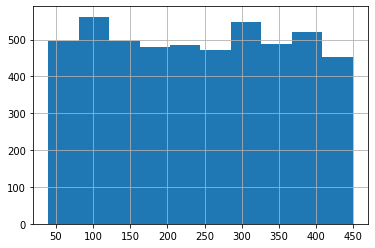

In [21]:
df["Time Spent"].hist();

Точка с запятой в конце строки с кодом для построения графиков скрывает вспомогательные объекты, которые создаются для отрисовки. Если мы не поставим её, мы увидим помимо графика массив с объектом `AxesSubplot` внутри:

<AxesSubplot:>

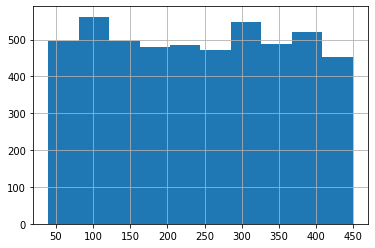

In [22]:
df["Time Spent"].hist()

Изменим цвет заливки и цвет границ столбцов:

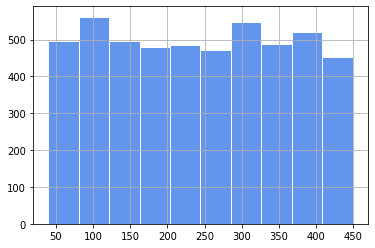

In [23]:
# color – заливка
# edgecolor – границы

df["Time Spent"].hist(color = "cornflowerblue", 
                      edgecolor = "w");

Что содержательного можно сказать о полученной гистограмме? Распределение показателя можно считать равномерным – все столбцы почти одинаковой высоты, а равномерное распределение одновременно является симметричным. При такой равномерности точно не наблюдается нехарактерных значений, если бы они были, мы увидели бы невысокие столбцы (нехарактерные значения – редкие, потому что если их много, они влияют на всё распределение, а значит, они для него уже не будут редкими), сильно отстоящие от других (нехарактерные значения – далекие от медианы/моды, вокруг которых обычно концентируются характерные значения).

Проиллюстрируем распределение с помощью ящика с усами:

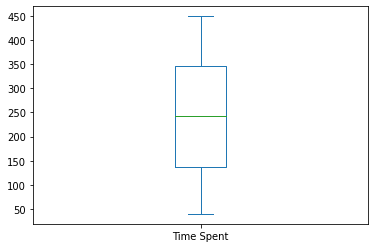

In [24]:
df["Time Spent"].plot.box();

Так и есть, зелёная линия, отвечающая за медиану, посередине ящика, примерно на одинаковом расстоянии от нижнего и верхнего квартиля, нижний и верхний ус ящика примерно одинаковой длины – это всё подтверждает симметричность распределения. 

Посмотрим на описание качественных (текстовых) столбцов. Метод `.describe()` и тут универсален:

In [25]:
print(df["Location"].describe())

count         5000
unique           4
top       Scotland
freq          1281
Name: Location, dtype: object


Выведем уникальные значения в столбце, их, как следует из выдачи выше, 4:

In [26]:
print(df["Location"].unique())

['Northern Ireland' 'Scotland' 'Wales' 'England']


Метод `.unique()` возвращает массив уникальных значений в том порядке, в котором они встречаются в датафрейме. Для сортировки можем воспользоваться сортировкой на массивах NumPy или просто базовой функцией `sorted()`, которая отсортирует любую последовательность:

In [27]:
print(sorted(df["Location"].unique()))

['England', 'Northern Ireland', 'Scotland', 'Wales']


Как описывать качественные данные? Во-первых, в качестве меры центральной тенденции выбрать моду (среднее и медиана не подходят):

In [28]:
print(df["Location"].mode())

0    Scotland
dtype: object


**Важно:** метод `.mode()`, в отличие от аналогичных `.mean()` и `.median()`, возвращает не одно значение, а последовательность `Series`, так как теоретически мода может быть не одна. Поэтому придётся забирать значение по индексу (для заполнения пропусков модой особо важно):

In [29]:
print(df["Location"].mode()[0])

Scotland


Во-вторых, можно зафиксировать частоты:

In [30]:
print(df["Location"].value_counts())

Scotland            1281
England             1246
Northern Ireland    1242
Wales               1231
Name: Location, dtype: int64


Метод `.value_counts()` возвращает пары *значение-частота* в порядке убывания частот. При желании можно выполнить сортировку по индексу или частоте:

In [31]:
# сортировка по индексу - по алфавиту
print(df["Location"].value_counts().sort_index())

England             1246
Northern Ireland    1242
Scotland            1281
Wales               1231
Name: Location, dtype: int64


In [32]:
# сортировка по значению - по возрастанию
print(df["Location"].value_counts().sort_values())

Wales               1231
Northern Ireland    1242
England             1246
Scotland            1281
Name: Location, dtype: int64


От абсолютных частот можем перейти к относительным, в долях:

In [33]:
print(df["Location"].value_counts(normalize = True))

Scotland            0.2562
England             0.2492
Northern Ireland    0.2484
Wales               0.2462
Name: Location, dtype: float64


И самостоятельно перейти к процентам:

In [34]:
print(df["Location"].value_counts(normalize = True) * 100)

Scotland            25.62
England             24.92
Northern Ireland    24.84
Wales               24.62
Name: Location, dtype: float64


В завершение описания качественных данных построим столбиковую диаграмму для `Location`. В отличие от гистограммы, этот тип графика строится не по исходному столбцу, а только по явному набору значений и их частот, то есть, например, по результату `.value_counts()`:

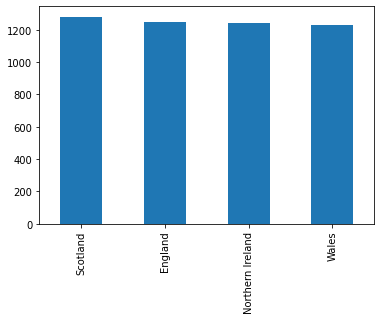

In [35]:
df["Location"].value_counts().plot.bar();

Также, в отличие от гистограммы, которая строится для одного ряда числовых значений и не подразумевает столбцы разного цвета (=разных категорий) по определению, в столбиковой диаграмме можно закрепить цвет за каждым столбцом отдельно:

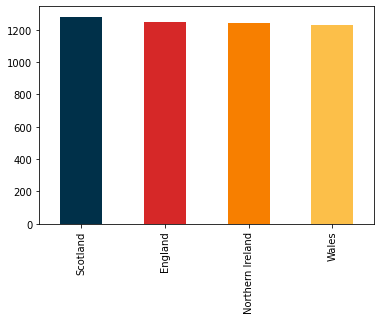

In [36]:
# цвета в формате HEX взяты из набора 
# готовых палитр https://coolors.co/palettes/trending

bars = ["#003049", "#D62828", "#F77F00", "#FCBF49"]
df["Location"].value_counts().plot.bar(color = bars);

Если цветов в списке меньше, чем столбцов, по окончании списка начинается повторение:

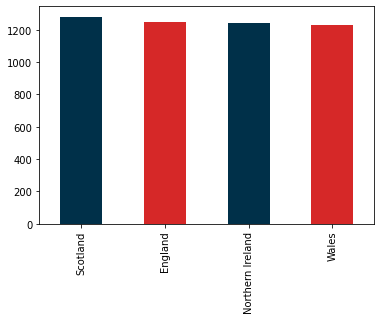

In [37]:
# так можно задать чередование двух цветов, например

bars = ["#003049", "#D62828"]
df["Location"].value_counts().plot.bar(color = bars);

### Работа со столбцами датафрейма: создание новых столбцов на основе старых

Теперь давайте посмотрим на более серьёзные способы создания новых столбцов на основе старых. Предположим, мы хотим обновить столбец `Conversion` на бинарный, заменив ответы `Yes` на 1, а `No` – на 0. Самый простой способ это сделать – проверить условие равенства:

In [38]:
df["Conversion"] == "Yes"

0       False
1       False
2       False
3       False
4        True
        ...  
4995    False
4996    False
4997    False
4998    False
4999    False
Name: Conversion, Length: 5000, dtype: bool

А полученный логический столбец из `True` и `False` сделать целочисленным, используя метод `.astype()`, который унаследован из NumPy:

In [39]:
df["Conversion"] = (df["Conversion"] == "Yes").astype(int)
print(df["Conversion"].value_counts()) # проверка

0    4515
1     485
Name: Conversion, dtype: int64


В более общем случае можем воспользоваться заменой через метод `.replace()` (ещё есть похожий метод `.map()`) и описать необходимые соответствия между старым и новым значением в виде словаря:

In [40]:
# A -> control, B -> treatment group

df["Group"] = df["Group"].replace({"A" : "Control", 
                                   "B" : "Treatment"})
print(df["Group"].value_counts()) # проверка

Control      2519
Treatment    2481
Name: Group, dtype: int64


Ещё более универсальный способ, который подойдёт не только для замен, но и для любых манипуляций, это написание своей анонимной lambda-функции и применение её ко всем значениям в столбце через метод `.apply()`:

In [41]:
# не добавляем в датафрейм, для иллюстрации
# x – содержимое одной ячейки,
# после : результат в ответ на это содержимое

print(df["Page Views"].apply(lambda x: 1 if x >= 4 else 0))

0       0
1       1
2       0
3       1
4       0
       ..
4995    1
4996    1
4997    1
4998    1
4999    1
Name: Page Views, Length: 5000, dtype: int64


Метод `.apply()` – аналог базового `map()`, только ещё более эффективный при работе с датафреймами. Он применяет написанную функцию к каждой ячейке в столбце (хотя его можно написать и для строк тоже, есть аргумент `axis`).

Конечно, если функция более объёмная, её лучше задать отдельно, а в `.apply()`подставить её название. Допустим, нас интересует количество слов в `Location`. Напишем функцию и применим её к столбцу:

In [42]:
def words_count(w):
    words = w.split()
    return len(words)

print(df["Location"].apply(words_count))

0       2
1       1
2       2
3       1
4       1
       ..
4995    1
4996    2
4997    1
4998    1
4999    2
Name: Location, Length: 5000, dtype: int64


### Переименование и удаление столбцов и строк

В примерах выше мы добавили столбцы, которые далее не понадобятся. Чтобы их удалить, потребуется метод `.drop()`. Стоит учесть, что этот метод умеет удалять как столбцы, так и строки, при этом со вторыми он работает по умолчанию. Поэтому если просто на вход подать список названий столбцов, ничего не произойдёт, так как Python будет искать *строки* с такими названиями:

In [43]:
# KeyError или отсутствие изменений
#df.drop(["Page Views", "Time Spent Min", "Time per View"])

Укажем явно название аргумента:

In [44]:
df.drop(columns = ["Page Views", "Time Spent Min", 
                   "Time per View"])

,User ID,Group,Time Spent,Conversion,Device,Location
0,14292,Treatment,424,0,Mobile,Northern Ireland
1,11682,Control,342,0,Mobile,Scotland
2,19825,Control,396,0,Desktop,Northern Ireland
3,16080,Treatment,318,0,Desktop,Wales
4,18851,Control,338,1,Desktop,Scotland
...,...,...,...,...,...,...
4995,16360,Treatment,313,0,Mobile,Wales
4996,18084,Treatment,313,0,Desktop,Northern Ireland
4997,12063,Control,156,0,Desktop,England
4998,18647,Treatment,346,0,Desktop,Wales


Забавно, но изменений всё ещё нет. Это связано с тем, что, несмотря на то, что тип `DataFrame` является изменяемым, многие методы на датафреймах по умолчанию работают «в безопасном режиме», то есть возвращают изменённую копию датафрейма, не изменяя оригинал. Чтобы сохранить изменения без переприсваивания через `=`, добавим аргумент `inplace = True`:

In [45]:
df.drop(columns = ["Page Views", "Time Spent Min", 
                  "Time per View"], inplace = True)
print(df.head()) # проверка

   User ID      Group  Time Spent  Conversion   Device          Location
0    14292  Treatment         424           0   Mobile  Northern Ireland
1    11682    Control         342           0   Mobile          Scotland
2    19825    Control         396           0  Desktop  Northern Ireland
3    16080  Treatment         318           0  Desktop             Wales
4    18851    Control         338           1  Desktop          Scotland


**NB.** При добавлении аргумента `inplace = True` метод `.drop()` «молча» вносит изменения в сам датафрейм и возвращает при этом пустой объект, поэтому сочетать присваивание и этот аргумент не стоит, в `df` останется `None`. Пример неверного сочетания:

    df = df.drop(columns = ["Page Views", "Time Spent Min", 
                  "Time per View"], inplace = True)

Метод `.rename()` работает ровно в той же логике, только замены при этом описываются через словарь. Переименуем некоторые столбцы  – сделаем названия покороче:

In [46]:
df.rename(columns = {"User ID" : "ID", "Time Spent": "Time"}, 
          inplace = True)

print(df.head())

      ID      Group  Time  Conversion   Device          Location
0  14292  Treatment   424           0   Mobile  Northern Ireland
1  11682    Control   342           0   Mobile          Scotland
2  19825    Control   396           0  Desktop  Northern Ireland
3  16080  Treatment   318           0  Desktop             Wales
4  18851    Control   338           1  Desktop          Scotland


### Группировка и агрегирование

Рассмотрим группировку строк в датафрейме по фиксированному признаку. Для группировки используется метод `.groupby()`, в качестве аргумента указывается столбец, по которому группируем:

In [47]:
print(df.groupby("Group"))

Этот метод возвращает скрытый объект специального типа, он временно хранится в какой-то ячейке памяти. Внутри этот объект похож на список кортежей, где на первом месте указаны значения показателя группировки, а на втором – датафрейм из строк, соответствующих этому значению.

In [48]:
print(*df.groupby("Group"))

('Control',          ID    Group  Time  Conversion   Device          Location
1     11682  Control   342           0   Mobile          Scotland
2     19825  Control   396           0  Desktop  Northern Ireland
4     18851  Control   338           1  Desktop          Scotland
6     16702  Control   106           0   Mobile  Northern Ireland
10    12776  Control   351           0  Desktop             Wales
...     ...      ...   ...         ...      ...               ...
4985  14687  Control   290           0   Mobile           England
4987  16251  Control   407           1  Desktop          Scotland
4991  14576  Control   110           0   Mobile             Wales
4997  12063  Control   156           0  Desktop           England
4999  16686  Control   208           0  Desktop  Northern Ireland

[2519 rows x 6 columns]) ('Treatment',          ID      Group  Time  Conversion   Device          Location
0     14292  Treatment   424           0   Mobile  Northern Ireland
3     16080  Treatme

Так, используя код выше, мы получаем пары:

* `Control` и датафрейм с отфильтрованными строками, соответствующими контрольной группе;
* `Treatment` и датафрейм с отфильтрованными строками, соответствующими тестовой группе (группе воздействия).

Если групп много (а не две, как здесь), этот результат удобно использовать для выгрузки данных по группам. Сделаем множественный перебор в `for` и сохраним датафрейм по каждой группе в CSV-файл:

In [49]:
for name, dat in df.groupby("Group"):
    dat.to_csv(name + ".csv")

Из результата группировки можно извлечь каждую группу отдельно (точнее, датафрейм, соответствующий каждой группе):

In [50]:
print(df.groupby("Group").get_group("Control"))

         ID    Group  Time  Conversion   Device          Location
1     11682  Control   342           0   Mobile          Scotland
2     19825  Control   396           0  Desktop  Northern Ireland
4     18851  Control   338           1  Desktop          Scotland
6     16702  Control   106           0   Mobile  Northern Ireland
10    12776  Control   351           0  Desktop             Wales
...     ...      ...   ...         ...      ...               ...
4985  14687  Control   290           0   Mobile           England
4987  16251  Control   407           1  Desktop          Scotland
4991  14576  Control   110           0   Mobile             Wales
4997  12063  Control   156           0  Desktop           England
4999  16686  Control   208           0  Desktop  Northern Ireland

[2519 rows x 6 columns]


Что удобно, объект, возвращаемый `.groupby()`, не просто список пар. Это особый тип в `pandas`, из которого можно извлекать столбцы по названиям, как в датафреймах. Так, если напишем следующий код:

In [51]:
print(df.groupby("Group")["Conversion"].describe())

            count      mean       std  min  25%  50%  75%  max
Group                                                         
Control    2519.0  0.053990  0.226042  0.0  0.0  0.0  0.0  1.0
Treatment  2481.0  0.140669  0.347750  0.0  0.0  0.0  0.0  1.0


`pandas` выберет из каждого датафрейма, соответствующего группе, столбец `Conversion` и вычислит по нему описательные статистики. Другими словами, можно сочетать группировку и агрегирование.

С другими методами это тоже работает:

In [52]:
# .sum() – здесь сумма 1, число выполнивших действие, по группам
# .mean() – здесь доля 1, доля выполнивших действие, по группам

print(df.groupby("Group")["Conversion"].sum())
print(df.groupby("Group")["Conversion"].mean())

Group
Control      136
Treatment    349
Name: Conversion, dtype: int64
Group
Control      0.053990
Treatment    0.140669
Name: Conversion, dtype: float64


Если нас интересует набор определенных функций, в не готовый выбор тех, что в `.describe()`, пригодится метод `.agg()`, сокращение от *aggregate*. В качестве аргумента можно использовать базовые функции Python – указываются без кавычек:

In [53]:
print(df.groupby("Group")["Conversion"].agg(sum))

Group
Control      136
Treatment    349
Name: Conversion, dtype: int64


Методы `pandas` – указываются в кавычках (или списком из строк):

In [54]:
print(df.groupby("Group")["Conversion"].agg("mean"))

Group
Control      0.053990
Treatment    0.140669
Name: Conversion, dtype: float64


In [56]:
print(df.groupby("Group")["Conversion"].agg(["sum", "mean"]))

           sum      mean
Group                   
Control    136  0.053990
Treatment  349  0.140669


И пользовательские функции, написанные через `def` или `lambda`:

In [57]:
print(df.groupby("Group")["Conversion"].agg(lambda x: 
                                            sum(x) / (len(x) - 1)))

Group
Control      0.054011
Treatment    0.140726
Name: Conversion, dtype: float64


Метод `.agg()` довольно гибкий. Иногда возникает необходимость для одних данных использовать одни описательные статистики, а для других – другие. Так, если медиана и среднее сильно различаются между собой, это свидетельствует о наличии нехарактерных значений (если среднее сильно больше медианы, нетипично больших, если среднее сильно меньше медианы, нетипично маленьких). А при наличии нехарактерных значений среднее арифметическое уже не является показательным, это неустойчивая оценка среднего.

В нашем случае ровно таких примеров нет, но мы можем по-разному описать `Conversion` и `Time`, поскольку первый показатель – бинарный, и нас, скорее, интересует просто доля 1, эквивалентная среднему, а второй – количественный:

In [58]:
df.groupby("Group")[["Conversion", "Time"]].agg({
    "Conversion" : "mean", "Time" : "median"})

,Conversion,Time
Group,,
Control,0.053990,241.0
Treatment,0.140669,244.0


Что удобно, результат группировки и агрегирования – обычный датафрейм, а его можно экспортировать в любой формат, в том числе в виде размеченного текста для статьи или отчёта:

In [59]:
# с округлением до сотых -> markdown

tab = df.groupby("Group")["Conversion"].agg(["sum", "mean"]).round(2)
print(tab.to_markdown())

| Group     |   sum |   mean |
|:----------|------:|-------:|
| Control   |   136 |   0.05 |
| Treatment |   349 |   0.14 |


In [60]:
# -> html
print(tab.to_html())

<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>sum</th>
      <th>mean</th>
    </tr>
    <tr>
      <th>Group</th>
      <th></th>
      <th></th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>Control</th>
      <td>136</td>
      <td>0.05</td>
    </tr>
    <tr>
      <th>Treatment</th>
      <td>349</td>
      <td>0.14</td>
    </tr>
  </tbody>
</table>


In [61]:
# -> latex
print(tab.to_latex())

\begin{tabular}{lrr}
\toprule
{} &  sum &  mean \\
Group     &      &       \\
\midrule
Control   &  136 &  0.05 \\
Treatment &  349 &  0.14 \\
\bottomrule
\end{tabular}



### Немного о мультииндексах

Выше мы рассмотрели пример группировки по одному основанию. Рассмотрим теперь группировку по двум основаниям и сгруппируем строки по типу сайта и устройству, с которого пользователи его открывали:

In [62]:
print(len(df.groupby(["Group", "Device"])))
# print(*df.groupby(["Group", "Device"]))

4


Групп получилось 4 (два типа сайта и два типа устройства). Если раскомментировать строку выше, можно увидеть, что теперь в качестве названий групп выступают пары – кортежи из двух строк. Пойдём дальше и выполним агрегирование:

In [63]:
df.groupby(["Group", "Device"])["Conversion"].agg(["sum", "mean"])

sum      mean
Group     Device                
Control   Desktop   73  0.058682
          Mobile    63  0.049412
Treatment Desktop  180  0.139104
          Mobile   169  0.142376

Так как теперь у нас есть два основания, два уровня группировки, второе основание (`Device`) оказалось «вложенным» в первое (`Group`). А значит, для выбора того же значения 73 из первой строки, нам придётся использовать мультииндексы – составные индексы в виде пары значений, как в раскомментированном результате `.groupby()` выше. Для удобства сохраним таблицу выше как `gr`:

In [64]:
gr = df.groupby(["Group", "Device"])["Conversion"].agg(["sum", "mean"])
gr

sum      mean
Group     Device                
Control   Desktop   73  0.058682
          Mobile    63  0.049412
Treatment Desktop  180  0.139104
          Mobile   169  0.142376

Посмотрим на индексы:

In [65]:
print(gr.index)

MultiIndex([(  'Control', 'Desktop'),
            (  'Control',  'Mobile'),
            ('Treatment', 'Desktop'),
            ('Treatment',  'Mobile')],
           names=['Group', 'Device'])


Действительно, объект типа `MultiIndex`, но внутри обычный список кортежей. 

Для выбора строк по индексам в `pandas` есть метод `.xs()`. В данном случае в него имеет смысл подставлять пару значений, если мы хотим забрать результаты по одной «маленькой» группе:

In [66]:
print(gr.xs(('Control', 'Desktop')))

sum     73.000000
mean     0.058682
Name: (Control, Desktop), dtype: float64


Если мы хотим сделать срез из результата группировки, то есть выбрать все результаты, относящиеся к какой-то группе на определённом уровне, можем использовать аргумент `level`:

In [67]:
# все для контрольной группы
# Control в первом уровне группировки с индексом 0

gr.xs('Control', level = 0)

,sum,mean
Device,,
Desktop,73,0.058682
Mobile,63,0.049412


In [68]:
# то же, но не по индексу, а по названию уровня
gr.xs('Control', level = "Group")

,sum,mean
Device,,
Desktop,73,0.058682
Mobile,63,0.049412


In [69]:
# второй уровень Device

gr.xs('Mobile', level = "Device")

,sum,mean
Group,,
Control,63,0.049412
Treatment,169,0.142376


### Фильтрация строк

Часто при работе с датафреймом нас интересует фильтрация наблюдений – выбор строк датафрейма, которые удовлетворяют определённому условию. Для этого интересующее нас условие необходимо указать в квадратных скобках.

In [70]:
# кто провел на сайте более 60 секунд
print(df[df["Time"] > 60])

         ID      Group  Time  Conversion   Device          Location
0     14292  Treatment   424           0   Mobile  Northern Ireland
1     11682    Control   342           0   Mobile          Scotland
2     19825    Control   396           0  Desktop  Northern Ireland
3     16080  Treatment   318           0  Desktop             Wales
4     18851    Control   338           1  Desktop          Scotland
...     ...        ...   ...         ...      ...               ...
4995  16360  Treatment   313           0   Mobile             Wales
4996  18084  Treatment   313           0  Desktop  Northern Ireland
4997  12063    Control   156           0  Desktop           England
4998  18647  Treatment   346           0  Desktop             Wales
4999  16686    Control   208           0  Desktop  Northern Ireland

[4745 rows x 6 columns]


Код выше работает по следующему принципу: проверка условия на столбце возвращает последовательность из `True` и `False`, а затем квадратные скобки обеспечивают фильтрацию – выбираются те строки из датафрейма, на которых было возвращено `True`.

Для объединения условий потребуются символьные операторы:

* `&` – аналог базового `and`;
* `|` – аналог базового `or`;
* `^` – оператор `xor`, в базовом Python в несимвольном виде отсутствует.

In [71]:
# кто провел на сайте более 60 секунд
# и заходил на него с компьютера

df[(df["Time"] > 60) & (df["Device"] == "Desktop")]

,ID,Group,Time,Conversion,Device,Location
2,19825,Control,396,0,Desktop,Northern Ireland
3,16080,Treatment,318,0,Desktop,Wales
4,18851,Control,338,1,Desktop,Scotland
5,13134,Treatment,93,0,Desktop,Scotland
8,13191,Treatment,434,0,Desktop,Northern Ireland
...,...,...,...,...,...,...
4994,14255,Treatment,258,0,Desktop,Wales
4996,18084,Treatment,313,0,Desktop,Northern Ireland
4997,12063,Control,156,0,Desktop,England
4998,18647,Treatment,346,0,Desktop,Wales


In [72]:
# пользователи из Англии или Уэльса

df[(df["Location"] == "England") | (df["Location"] == "Wales")]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


In [73]:
# то же, только с xor, хотя здесь неисключающее ИЛИ
# и исключающее ИЛИ эквивалентны

df[(df["Location"] == "England") ^ (df["Location"] == "Wales")]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


**NB.** Круглые скобки вокруг частей условия важны. Символьные операторы в Python – сильные, поэтому без скобок условия выше будут обрабатываться с середины. В дааном примере

    df["Location"] == "England" ^ df["Location"] == "Wales"
    
Python попытается начать с `^` и объединить через исключающее «или» строку `"England"` и столбец `df["Location"]`, что приведёт к ошибке – исключению `TypeError`.

Однако иногда для формулировки условий стандартных операторов (`&`, `|`, `^`) недостаточно. Чтобы не писать длинную последовательность с `|`, можно проверить, входят ли значения в некотором столбце в список, с помощью метода `.isin()`:

In [74]:
# isin() возвращает True/False

df[df["Location"].isin(["England", "Wales"])]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
9,14427,Treatment,271,0,Desktop,England
10,12776,Control,351,0,Desktop,Wales
11,11457,Control,347,0,Mobile,England
12,16270,Treatment,123,0,Desktop,Wales
...,...,...,...,...,...,...
4993,14608,Treatment,89,0,Mobile,England
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
4997,12063,Control,156,0,Desktop,England


Метод `.isin()` выполняет поиск точных соответствий (строгое совпадение с каким-нибудь элементом внутри списка), для проверки частичных совпадений можно воспользоваться методами из модуля `str`. Это набор методов на строках внутри `pandas`, который включает те же операции на строках, что и в базовом Python (вроде `.split()` или `.lower()` и `.upper()`), только здесь методы векторизованные – применяются не к одной строке, а к столбцу строк сразу. 

При этом в `str` определены методы, которых в базовом наборе функций на строках отсутствуют. Так, в `str` есть метод `.contains()`, который проверяет, содержит ли текст в ячейке некоторую подстроку:

In [75]:
df[df["Location"].str.contains("land")]

,ID,Group,Time,Conversion,Device,Location
0,14292,Treatment,424,0,Mobile,Northern Ireland
1,11682,Control,342,0,Mobile,Scotland
2,19825,Control,396,0,Desktop,Northern Ireland
4,18851,Control,338,1,Desktop,Scotland
5,13134,Treatment,93,0,Desktop,Scotland
...,...,...,...,...,...,...
4992,13803,Treatment,47,1,Desktop,England
4993,14608,Treatment,89,0,Mobile,England
4996,18084,Treatment,313,0,Desktop,Northern Ireland
4997,12063,Control,156,0,Desktop,England


При этом методы внутри `str` по умолчанию поддерживают работу с регулярными выражениями. Если эту поддержку не выключать, можно сразу внутри строки писать нужный шаблон. В целом, если вы уверенно владеете регулярными выражениями, для поиска по частичным совпадениям достаточно метода `.contains()`, но, как частные случаи, в этом наборе методов есть функции `.startswith()` и `.endswith()`, которые проверяют, начинается ли/заканчивается ли строка на определённую последовательность символов.

В заключение посмотрим на формулировку отрицания:

In [76]:
# отрицание - оператор ~

df[~df["Location"].str.contains("land")]

,ID,Group,Time,Conversion,Device,Location
3,16080,Treatment,318,0,Desktop,Wales
10,12776,Control,351,0,Desktop,Wales
12,16270,Treatment,123,0,Desktop,Wales
16,14091,Control,377,0,Mobile,Wales
17,18448,Treatment,95,0,Mobile,Wales
...,...,...,...,...,...,...
4988,12584,Treatment,159,0,Desktop,Wales
4991,14576,Control,110,0,Mobile,Wales
4994,14255,Treatment,258,0,Desktop,Wales
4995,16360,Treatment,313,0,Mobile,Wales
